# Train Three Attack-Family-Specific Hybrid Models

Trains THREE separate hybrid models (XGBoost + Isolation Forest, same
25-feature set as the deployed model), one per structural attack family,
instead of one generalist model covering everything:

1. RAW FLOODS (models/family_raw_flood/) - connectionless, near-zero
   forward payload: raw crafted packets thrown at the victim with no
   real content. Matches this project's live ICMP/SYN/UDP flood
   simulator scenarios most closely. CIC-DDoS2019's Syn + TFTP, plus
   CIC-IDS2018's "DDOS attack-LOIC-UDP" (LOIC's UDP-flood mode -
   connectionless, unlike LOIC's HTTP mode which is family 3).

2. REFLECTION / AMPLIFICATION FLOODS (models/family_reflection/) -
   also connectionless (no handshake), but structurally different from
   family 1: large forward payload, because these packets carry a real
   server response from a spoofed reflector (DNS/NTP/SSDP/LDAP/SNMP/
   NetBIOS/MSSQL/Portmap answering a forged request). This is exactly
   the feature profile that dominated Min Pkt Size importance (51-59%,
   tripping the shortcut-warning threshold) when this data was earlier
   pooled with family 1 under one "volumetric" label - splitting it out
   removes that internal heterogeneity instead of disclosing and
   tolerating it. All 14 of CIC-DDoS2019's reflection-style labels:
   UDP, UDP-lag, DrDoS_DNS, DrDoS_LDAP, DrDoS_MSSQL, DrDoS_NTP,
   DrDoS_NetBIOS, DrDoS_SNMP, DrDoS_SSDP, DrDoS_UDP, LDAP, MSSQL,
   NetBIOS, Portmap.

3. CONNECTION / APPLICATION-LAYER ATTACKS (models/family_connection/) -
   a real connection or session actually forms: full TCP handshake for
   HTTP-style DoS/brute-force/injection attacks, or scan/infiltration
   behavior. Matches this project's live HTTP flood / port scan
   scenarios. All 13 remaining CIC-IDS2018 attack types (Hulk,
   GoldenEye, Slowloris, SlowHTTPTest, Infilteration, DDOS attack-HOIC,
   DDoS attacks-LOIC-HTTP, Bot, Brute Force -Web, Brute Force -XSS, SQL
   Injection, FTP-BruteForce, SSH-Bruteforce) plus CIC-DDoS2019's
   WebDDoS.

Together these three families cover EVERY attack label present in the
local CIC-IDS2018 (28 offset windows + 3 full days) and CIC-DDoS2019 (18
attack-type files) data - nothing is dropped as "doesn't fit any
family" the way an earlier, narrower version of this split did (only
Syn/TFTP + Hulk/GoldenEye/Slowloris/SlowHTTPTest/Infilteration, leaving
~85% of 2019's attack rows and several 2018 attack types unrepresented
in any model). Change RAW_FLOOD_LABELS_*, REFLECTION_LABELS_*, and
CONNECTION_LABELS_* below to adjust the split - every label appearing
in the data should be in exactly one of the six lists.

Each source file/day still contributes only its own benign rows (the
project's established "own benign only per file" convention, avoiding a
capture-session shortcut) - a 2018 day whose attack rows get split
across multiple families contributes its own benign rows to EACH
derived dataset it appears in (this is reusing that day's own authentic
benign traffic for separate binary tasks, not cross-session blending,
since every dataset pulls from the exact same source rows).

Architecture/hyperparameters, scaling, and threshold-tuning logic are
otherwise unchanged from retrain_deployed_model.py, for continuity and
comparability with the deployed model. Threshold is tuned against
detection/predictor.py's actual OR-combination logic, same as there.

Outputs to models/family_volumetric/ and models/family_connection/ -
NOT the live models/ path - each with its own xgb_model.pkl,
isolation_forest.pkl, scaler.pkl, threshold.pkl, top_features.pkl,
provenance.json. Not wired into serving code; this only trains and
reports metrics.

Usage:
    python train_attack_family_models.py

In [1]:
import json
import pickle
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

## Config - paths, feature set, family definitions

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PARTIAL_DIR = PROJECT_ROOT / "data" / "cicids2018"
PARTIAL_DAYS = [
    "02-14-2018_off0.csv", "02-14-2018_off1.csv", "02-14-2018_off2.csv", "02-14-2018_off3.csv",
    "02-15-2018_off0.csv", "02-15-2018_off1.csv", "02-15-2018_off2.csv", "02-15-2018_off3.csv",
    "02-16-2018_off0.csv", "02-16-2018_off1.csv", "02-16-2018_off2.csv", "02-16-2018_off3.csv",
    "02-20-2018_off0.csv", "02-20-2018_off1.csv", "02-20-2018_off2.csv", "02-20-2018_off3.csv",
    "02-21-2018_off0.csv", "02-21-2018_off1.csv", "02-21-2018_off2.csv", "02-21-2018_off3.csv",
    "02-22-2018_off0.csv", "02-22-2018_off1.csv", "02-22-2018_off2.csv", "02-22-2018_off3.csv",
    "02-23-2018_off0.csv", "02-23-2018_off1.csv", "02-23-2018_off2.csv", "02-23-2018_off3.csv",
]
FULL_DIR = PROJECT_ROOT / "data" / "cicids2018_full"
FULL_DAYS = ["02-28-2018.csv", "03-01-2018.csv", "03-02-2018.csv"]

DDOS2019_SAMPLE = PROJECT_ROOT / "data" / "ddos2019_sample" / "combined_sample_25feature.csv"

with open(PROJECT_ROOT / "models" / "top_features.pkl", "rb") as f:
    TOP_FEATURES = pickle.load(f)

DERIVED = {"pkt_rate_ratio", "iat_variation"}
RAW_NEEDED_2018 = [c for c in TOP_FEATURES if c not in DERIVED]

# Every attack label found in the local data should appear in exactly
# one of these six lists - see the intro cell for the reasoning behind
# each placement.
RAW_FLOOD_LABELS_2019 = ["Syn", "TFTP"]
RAW_FLOOD_LABELS_2018 = ["DDOS attack-LOIC-UDP"]

REFLECTION_LABELS_2019 = [
    "UDP", "UDP-lag",
    "DrDoS_DNS", "DrDoS_LDAP", "DrDoS_MSSQL", "DrDoS_NTP", "DrDoS_NetBIOS",
    "DrDoS_SNMP", "DrDoS_SSDP", "DrDoS_UDP",
    "LDAP", "MSSQL", "NetBIOS", "Portmap",
]
REFLECTION_LABELS_2018 = []

CONNECTION_LABELS_2019 = ["WebDDoS"]
CONNECTION_LABELS_2018 = [
    "DoS attacks-Hulk", "DoS attacks-GoldenEye", "DoS attacks-Slowloris", "DoS attacks-SlowHTTPTest",
    "Infilteration", "DDOS attack-HOIC", "DDoS attacks-LOIC-HTTP",
    "Bot", "Brute Force -Web", "Brute Force -XSS", "SQL Injection",
    "FTP-BruteForce", "SSH-Bruteforce",
]

FAMILIES = {
    "raw_flood": (RAW_FLOOD_LABELS_2018, RAW_FLOOD_LABELS_2019),
    "reflection": (REFLECTION_LABELS_2018, REFLECTION_LABELS_2019),
    "connection_application_layer": (CONNECTION_LABELS_2018, CONNECTION_LABELS_2019),
}

## Loaders (identical to `retrain_deployed_model.py`)

In [3]:
def load_one_2018_day(path):
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    df = df[df["Label"] != "Label"].reset_index(drop=True)
    df["Label"] = df["Label"].str.strip()

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
    df = df.dropna(subset=["Timestamp"])
    df["Binary_Label"] = df["Label"].apply(lambda x: 0 if str(x).strip().lower() == "benign" else 1)

    for col in RAW_NEEDED_2018 + ["Flow Pkts/s", "Fwd Pkts/s", "Flow IAT Mean", "Flow IAT Std"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["pkt_rate_ratio"] = df["Fwd Pkts/s"] / (df["Flow Pkts/s"] + 1)
    df["iat_variation"] = df["Flow IAT Std"] / (df["Flow IAT Mean"] + 1)

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=TOP_FEATURES)
    df["day"] = path.stem
    return df.sort_values("Timestamp").reset_index(drop=True)


def load_ddos2019_sample():
    if not DDOS2019_SAMPLE.exists():
        raise FileNotFoundError(
            f"{DDOS2019_SAMPLE} not found - run fetch_ddos2019_sample_25feature.py first"
        )
    df = pd.read_csv(DDOS2019_SAMPLE, low_memory=False)
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["Label"] = df["Label"].str.strip()
    return [g.sort_values("Timestamp").reset_index(drop=True) for _, g in df.groupby("day")]


def per_day_split(day_df):
    attacks = day_df.loc[day_df["Binary_Label"] == 1, "Timestamp"]
    if len(attacks) < 20:
        cutoff = day_df["Timestamp"].quantile(0.8)
    else:
        cutoff = attacks.quantile(0.7)
    train_mask = (day_df["Timestamp"] < cutoff).values
    return train_mask, ~train_mask

## Load everything once + verify full label coverage

Loading all 2018/2019 day-frames once up front (rather than per-family) since the full 2018 days are 600MB-1GB each - reloading them 3x would triple the slowest part of this notebook. The coverage check below should print "all attack labels ... covered" - if it doesn't, one of the six label lists above is out of date with your local data files.

In [4]:
print("loading all CIC-IDS2018 day-frames (28 offset windows + 3 full days) ...")
all_2018_frames = [load_one_2018_day(PARTIAL_DIR / n) for n in PARTIAL_DAYS]
all_2018_frames += [load_one_2018_day(FULL_DIR / n) for n in FULL_DAYS]
print(f"  {len(all_2018_frames)} 2018 day-frames loaded")

print("loading all CIC-DDoS2019 day-frames (18 attack-type files) ...")
all_2019_frames = load_ddos2019_sample()
print(f"  {len(all_2019_frames)} 2019 day-frames loaded")

all_2018_labels = {l for df in all_2018_frames for l in df.loc[df.Binary_Label == 1, "Label"].unique()}
all_2019_labels = {l for df in all_2019_frames for l in df.loc[df.Binary_Label == 1, "Label"].unique()}
assigned_2018 = set().union(*[labels_2018 for labels_2018, _ in FAMILIES.values()])
assigned_2019 = set().union(*[labels_2019 for _, labels_2019 in FAMILIES.values()])
unassigned_2018 = all_2018_labels - assigned_2018
unassigned_2019 = all_2019_labels - assigned_2019
if unassigned_2018 or unassigned_2019:
    print(f"WARNING: labels present in the data but not assigned to any family: "
          f"2018={sorted(unassigned_2018)} 2019={sorted(unassigned_2019)}")
else:
    print("all attack labels found in the local data are covered by one of the three families.")

loading all CIC-IDS2018 day-frames (28 offset windows + 3 full days) ...
  31 2018 day-frames loaded
loading all CIC-DDoS2019 day-frames (18 attack-type files) ...
  18 2019 day-frames loaded
all attack labels found in the local data are covered by one of the three families.


## Build the three family-specific datasets

In [5]:
def select_2019_frames(all_2019_frames, labels):
    """Each 2019 file is single-attack-type + its own sparse benign rows -
    keep the whole file if its one attack label belongs to this family,
    skip it entirely otherwise."""
    kept = []
    for day_df in all_2019_frames:
        file_labels = set(day_df.loc[day_df["Binary_Label"] == 1, "Label"].unique())
        if file_labels & set(labels):
            kept.append(day_df)
    return kept


def select_2018_frames(all_2018_frames, labels):
    """2018 days mix many attack types - keep that day's own benign rows
    plus only the attack rows whose label is in this family; drop the
    rest of that day's attack rows (they belong to another family, not
    absent from the data)."""
    kept = []
    for day_df in all_2018_frames:
        keep_mask = (day_df["Binary_Label"] == 0) | (day_df["Label"].isin(labels))
        filtered = day_df[keep_mask].reset_index(drop=True)
        if filtered.empty or (filtered["Binary_Label"] == 1).sum() == 0:
            continue
        kept.append(filtered)
    return kept


def build_family_dataset(all_2018_frames, all_2019_frames, labels_2018, labels_2019):
    frames = select_2019_frames(all_2019_frames, labels_2019) + select_2018_frames(all_2018_frames, labels_2018)

    if not frames:
        raise ValueError(f"no rows matched labels_2018={labels_2018} or labels_2019={labels_2019}")

    train_parts, test_parts = [], []
    for day_df in frames:
        tr, te = per_day_split(day_df)
        train_parts.append(day_df[tr])
        test_parts.append(day_df[te])
        atk = day_df["Binary_Label"]
        found_labels = sorted(day_df.loc[atk == 1, "Label"].unique())
        print(f"  {day_df['day'].iloc[0]}: {len(day_df)} rows {found_labels}, "
              f"train={tr.sum()} (attack={atk[tr].sum()}), test={te.sum()} (attack={atk[te].sum()})")

    return pd.concat(train_parts, ignore_index=True), pd.concat(test_parts, ignore_index=True)

## Shared train/eval/save (identical methodology to `retrain_deployed_model.py`)

In [6]:
def tune_threshold(y_true, probs):
    return float(max(np.linspace(0, 1, 100), key=lambda v: f1_score(y_true, probs >= v, zero_division=0)))


def eval_hybrid(y_true, xgb_probs, isolation_preds, threshold):
    """Mirrors detection/predictor.py's actual combination logic exactly:
    hybrid = (xgb_probability >= threshold) OR (isolation_prediction == 1)."""
    xgb_pred = (xgb_probs >= threshold).astype(int)
    hybrid_pred = ((xgb_pred == 1) | (isolation_preds == 1)).astype(int)
    return {
        "accuracy": accuracy_score(y_true, hybrid_pred),
        "precision": precision_score(y_true, hybrid_pred, zero_division=0),
        "recall": recall_score(y_true, hybrid_pred, zero_division=0),
        "f1": f1_score(y_true, hybrid_pred, zero_division=0),
    }


def feature_importance_report(names, importances):
    report = sorted(zip(names, [float(i) for i in importances]), key=lambda x: -x[1])
    shortcut_warning = report[0][1] > 0.5
    return report, shortcut_warning


def per_label_recall(test_df, xgb_probs, isolation_preds, threshold):
    """Breaks recall down by the original (non-binary) attack Label, so
    heterogeneity within a family is visible rather than averaged away."""
    xgb_pred = (xgb_probs >= threshold).astype(int)
    hybrid_pred = ((xgb_pred == 1) | (isolation_preds == 1)).astype(int)
    rows = []
    for label in sorted(test_df.loc[test_df["Binary_Label"] == 1, "Label"].unique()):
        mask = (test_df["Label"] == label).values
        n = int(mask.sum())
        if n == 0:
            continue
        rows.append({"label": label, "n": n, "recall": float(hybrid_pred[mask].mean())})
    return rows


def train_family_model(family_name, dataset_description, train_df, test_df, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'=' * 70}\ntraining: {family_name}\n{'=' * 70}")
    print(f"train={len(train_df)} test={len(test_df)}")
    print(f"train attack ratio: {train_df['Binary_Label'].mean():.3f}")
    print(f"test attack ratio:  {test_df['Binary_Label'].mean():.3f}")
    print(f"attack labels in this family: {sorted(train_df.loc[train_df.Binary_Label == 1, 'Label'].unique())}")

    X_train = train_df[TOP_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_train = np.clip(X_train, -1e9, 1e9).astype(np.float64)
    y_train = train_df["Binary_Label"].values

    X_test = test_df[TOP_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = np.clip(X_test, -1e9, 1e9).astype(np.float64)
    y_test = test_df["Binary_Label"].values

    scaler = RobustScaler()
    X_benign_train = X_train[y_train == 0]
    X_benign_scaled = scaler.fit_transform(X_benign_train)
    X_test_scaled = scaler.transform(X_test)

    print("training Isolation Forest (benign-only) ...")
    iso = IsolationForest(
        n_estimators=500, max_samples=512, contamination=0.12,
        max_features=0.8, random_state=42, n_jobs=-1,
    )
    iso.fit(X_benign_scaled)
    isolation_preds_test = (iso.predict(X_test_scaled) == -1).astype(int)

    print("training XGBoost ...")
    xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0, eval_metric="logloss",
        n_jobs=-1, random_state=42,
    )
    xgb.fit(X_train, y_train)
    xgb_probs_test = xgb.predict_proba(X_test)[:, 1]

    threshold = tune_threshold(y_test, xgb_probs_test)
    metrics = eval_hybrid(y_test, xgb_probs_test, isolation_preds_test, threshold)
    print(f"tuned threshold: {threshold}")
    print(f"hybrid metrics (xgb>=threshold OR isolation) on held-out data: {metrics}")

    imp, shortcut_warning = feature_importance_report(TOP_FEATURES, xgb.feature_importances_)
    print(f"shortcut_warning: {shortcut_warning}")

    isolation_only_recall = recall_score(y_test, isolation_preds_test, zero_division=0)
    xgb_only_pred = (xgb_probs_test >= threshold).astype(int)
    xgb_only_metrics = {
        "accuracy": accuracy_score(y_test, xgb_only_pred),
        "precision": precision_score(y_test, xgb_only_pred, zero_division=0),
        "recall": recall_score(y_test, xgb_only_pred, zero_division=0),
        "f1": f1_score(y_test, xgb_only_pred, zero_division=0),
    }
    print(f"xgb-alone metrics at tuned threshold: {xgb_only_metrics}")
    print(f"isolation-forest-alone recall: {isolation_only_recall}")

    per_label = per_label_recall(test_df, xgb_probs_test, isolation_preds_test, threshold)
    print("per-attack-label recall (held out):")
    for row in per_label:
        print(f"  {row['label']:<20} n={row['n']:<8} recall={row['recall']:.3f}")

    with open(out_dir / "xgb_model.pkl", "wb") as f:
        pickle.dump(xgb, f)
    with open(out_dir / "isolation_forest.pkl", "wb") as f:
        pickle.dump(iso, f)
    with open(out_dir / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(out_dir / "threshold.pkl", "wb") as f:
        pickle.dump(threshold, f)
    with open(out_dir / "top_features.pkl", "wb") as f:
        pickle.dump(TOP_FEATURES, f)

    provenance = {
        "created_at": datetime.now(timezone.utc).isoformat(),
        "family": family_name,
        "dataset": dataset_description,
        "day_tags": sorted(pd.concat([train_df, test_df])["day"].unique().tolist()),
        "attack_labels": sorted(pd.concat([train_df, test_df]).loc[
            pd.concat([train_df, test_df])["Binary_Label"] == 1, "Label"].unique().tolist()),
        "train_rows": int(len(train_df)),
        "test_rows": int(len(test_df)),
        "hybrid_metrics_held_out": metrics,
        "xgb_alone_metrics_held_out": xgb_only_metrics,
        "isolation_alone_recall_held_out": float(isolation_only_recall),
        "per_attack_label_recall_held_out": per_label,
        "feature_importances": imp,
        "shortcut_warning": shortcut_warning,
        "threshold": threshold,
    }
    with open(out_dir / "provenance.json", "w", encoding="utf-8") as f:
        json.dump(provenance, f, indent=2, default=str)

    print(f"saved artifacts to {out_dir}/")
    return provenance

## Train all three families

`raw_flood` -> `models/family_raw_flood/`, `reflection` -> `models/family_reflection/`, `connection_application_layer` -> `models/family_connection/`. None of these touch the live `models/` path.

In [7]:
provenances = {}
for family_name, (labels_2018, labels_2019) in FAMILIES.items():
    print(f"\nbuilding {family_name.upper()} dataset ...")
    train_df, test_df = build_family_dataset(all_2018_frames, all_2019_frames, labels_2018, labels_2019)
    dataset_description = (
        ("CIC-IDS2018 " + ", ".join(labels_2018) if labels_2018 else "")
        + (" + " if labels_2018 and labels_2019 else "")
        + ("CIC-DDoS2019 " + ", ".join(labels_2019) if labels_2019 else "")
        + " - own benign only per file/day"
    )
    provenances[family_name] = train_family_model(
        family_name, dataset_description, train_df, test_df,
        PROJECT_ROOT / "models" / f"family_{family_name.replace('_application_layer', '')}",
    )


building RAW_FLOOD dataset ...
  2019_01-12_Syn: 36559 rows ['Syn'], train=25576 (attack=25573), test=10983 (attack=10961)
  2019_01-12_TFTP: 36782 rows ['TFTP'], train=25176 (attack=25171), test=11606 (attack=10788)
  2019_03-11_Syn: 37668 rows ['Syn'], train=26345 (attack=26345), test=11323 (attack=11291)
  02-21-2018_off0: 3933 rows ['DDOS attack-LOIC-UDP'], train=2943 (attack=1210), test=990 (attack=520)

training: raw_flood
train=80040 test=34902
train attack ratio: 0.978
test attack ratio:  0.962
attack labels in this family: ['DDOS attack-LOIC-UDP', 'Syn', 'TFTP']
training Isolation Forest (benign-only) ...
training XGBoost ...
tuned threshold: 0.98989898989899
hybrid metrics (xgb>=threshold OR isolation) on held-out data: {'accuracy': 0.9763337344564781, 'precision': 0.9760339712640335, 'recall': 0.9999404052443385, 'f1': 0.9878425716051926}
xgb-alone metrics at tuned threshold: {'accuracy': 0.9960174202051458, 'precision': 0.9960813418435506, 'recall': 0.9997914183551847, 'f1

## Summary

In [8]:
print(f"{'=' * 70}\nSUMMARY\n{'=' * 70}")
for family_name, prov in provenances.items():
    m = prov["hybrid_metrics_held_out"]
    print(f"{family_name}: train={prov['train_rows']} test={prov['test_rows']} "
          f"acc={m['accuracy']:.3f} prec={m['precision']:.3f} rec={m['recall']:.3f} f1={m['f1']:.3f} "
          f"shortcut_warning={prov['shortcut_warning']}")

SUMMARY
raw_flood: train=80040 test=34902 acc=0.976 prec=0.976 rec=1.000 f1=0.988 shortcut_warning=False
reflection: train=430714 test=185355 acc=0.993 prec=0.993 rec=1.000 f1=0.996 shortcut_warning=True
connection_application_layer: train=1993445 test=587434 acc=0.855 prec=0.820 rec=0.864 f1=0.842 shortcut_warning=False


## Visualizations

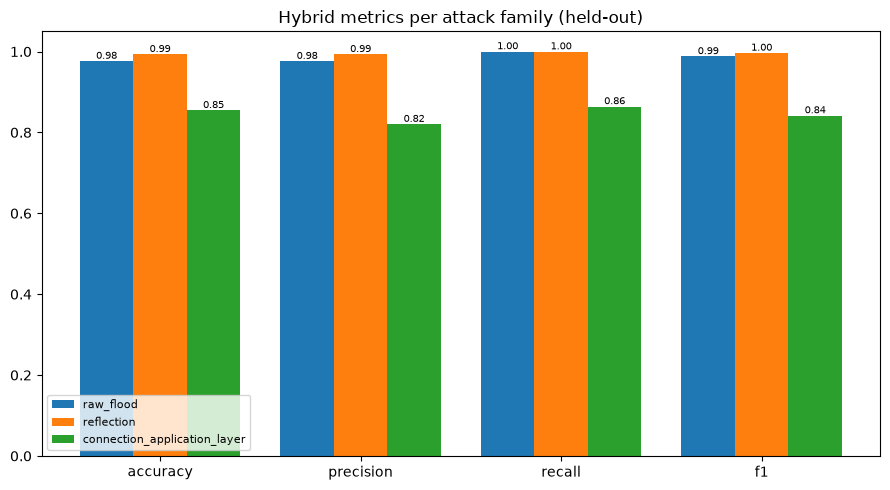

In [9]:
import matplotlib.pyplot as plt

family_names = list(provenances.keys())
metric_names = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metric_names))
width = 0.8 / len(family_names)

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(family_names):
    values = [provenances[name]["hybrid_metrics_held_out"][k] for k in metric_names]
    bars = ax.bar(x + i * width - 0.4 + width / 2, values, width, label=name)
    for bar, v in zip(bars, values):
        ax.annotate(f"{v:.2f}", (bar.get_x() + bar.get_width() / 2, v), ha="center", va="bottom", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_title("Hybrid metrics per attack family (held-out)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

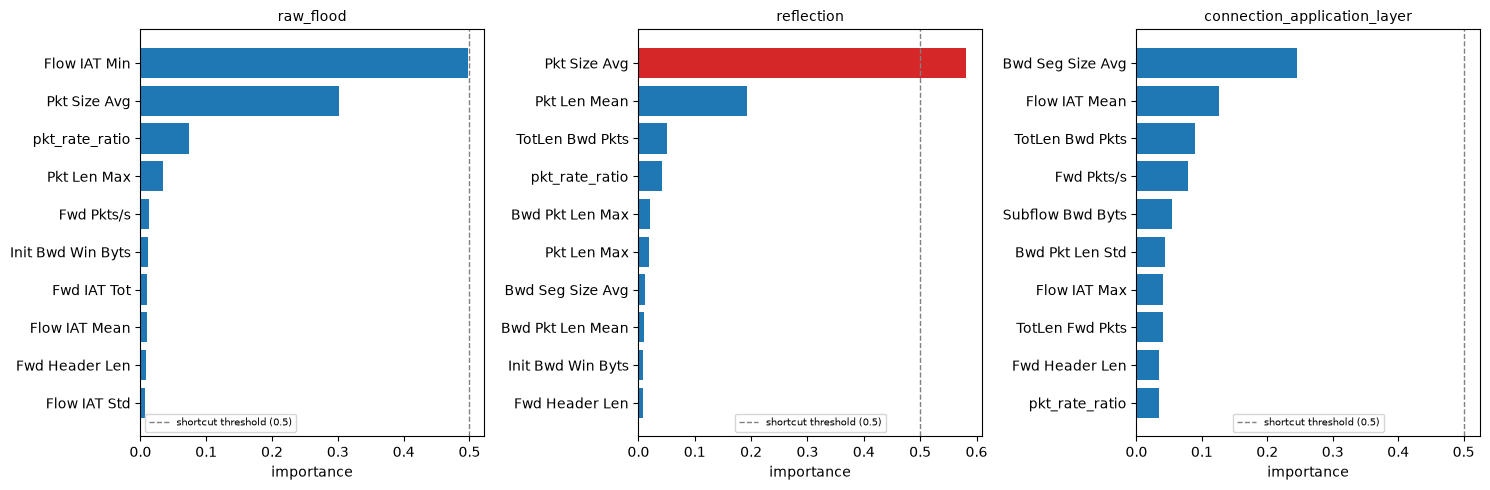

In [10]:
fig, axes = plt.subplots(1, len(family_names), figsize=(5 * len(family_names), 5))
for ax, name in zip(axes, family_names):
    imp = provenances[name]["feature_importances"][:10]
    names = [n for n, _ in imp][::-1]
    values = [v for _, v in imp][::-1]
    colors = ["#d62728" if v > 0.5 else "#1f77b4" for v in values]
    ax.barh(names, values, color=colors)
    ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, label="shortcut threshold (0.5)")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("importance")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()